# Setup

In [4]:
import pandas as pd
import spacy
from spellchecker import SpellChecker
from gensim.test.utils import common_texts
from gensim.models import Word2Vec, KeyedVectors
import re
import importlib
import utils
import calculate_linguisticFeatures
import numpy as np

importlib.reload(utils)
importlib.reload(calculate_linguisticFeatures)

<module 'calculate_linguisticFeatures' from 'c:\\Projetos\\mineracao_arquivos_epstein_2026\\calculate_linguisticFeatures.py'>

# Datasets raw

In [2]:
# dt.to_csv('misspellings.csv', sep='|', index=False)

In [3]:
dt_raw = utils.Utils.load('/datasets/raw', 1,2,3,4,5,6,7,8,10,12)

NameError: name 'utils' is not defined

In [ ]:
dt_raw['file_type'] = dt_raw['file'].apply(lambda x: x.split('.')[-1])
dt_raw['file_type'] = dt_raw['file_type'].replace({
    'mp4':'video',
    'avi':'video',
    'mov': 'video',
    'm4v': 'video',
    'mp3':'audio',
    'm4a':'audio',
    'wav': 'audio',
    'xlsx': 'sheet',
    'xls': 'sheet',
    'csv': 'sheet',
})
#PDFs sem texto são todos imagens
dt_raw.loc[dt_raw['content'].isna(), 'file_type'] = 'image'

#dropar duplicatas vazias que não são imagens
dt_raw.loc[dt_raw['file_type'] == 'pdf', 'content'] = dt_raw.loc[dt_raw['file_type'] == 'pdf', 'content'].replace({'failed': np.nan})
dt_raw = dt_raw.sort_values('content', na_position='first')
dt_raw = dt_raw.drop_duplicates('file', keep='last')

dt_raw['file_type'].value_counts().to_frame().style

,count
file_type,
pdf,222895
image,7966
video,1226
audio,27
sheet,16
opus,16
amr,5
pluginpayloadattachment,1
3gp,1


In [ ]:
linguistics = calculate_linguisticFeatures.linguisticFeatures()

# Pré processamento de textos e cálculo de tokens, OOV e orações

In [ ]:
# dt = dt_raw.loc[dt_raw['file_type'] == 'pdf']
# dt = dt.dropna()

In [ ]:
# dt.loc[0, 'preprocessed_text'] = ''
# for i in range(dt.shape[0]):
#   dtemp = linguistics.get(
#       dt['content'].iloc[i],
#       'preprocess',
#   )
#   dt.iloc[i, 5] = dtemp['preprocess'][0]
#   if i%100 == 0:
#     dt.to_csv(f'datasets-preprocess.csv', sep='|', index=False)
# dt.to_csv(f'datasets-preprocess.csv', sep='|', index=False)

In [ ]:
# dt.loc[0, ['count_tokens', 'count_misspellings', 'count_sentences']] = 0
# for i in range(dt.shape[0]):
#   dtemp = linguistics.get(
#       dt['preprocessed_text'].iloc[i],
#       'count_tokens',
#       'count_misspellings',
#       'count_sentences',
#   )
#   dt.iloc[i, [6,7,8]] = dtemp
#   if i%100 == 0:
#     dt.to_csv(f'datasets-misspellings.csv', sep='|', index=False)
# dt.to_csv(f'datasets-misspellings.csv', sep='|', index=False)

## Filtros

In [ ]:
dt = pd.read_csv('datasets/dataset_processed.csv', sep='|')

In [ ]:
dt['count_tokens'].value_counts()

count_tokens
73.0      2969
50.0      2333
72.0      2323
74.0      2247
68.0      2219
          ... 
5175.0       1
5282.0       1
3466.0       1
7131.0       1
2615.0       1
Name: count, Length: 3371, dtype: int64

In [ ]:
dt['ratio_misspelling'] = dt['count_misspellings']/dt['count_tokens']
dt.sort_values('ratio_misspelling', ascending=False)

,dataset,file,content,file_type,len,preprocessed_text,count_tokens,count_misspellings,count_sentences,ratio_misspelling
31,1.0,EFTA00000312.pdf,IL\r\n,pdf,4.0,il,1.0,1.0,1.0,1.0
9,1.0,EFTA00000090.pdf,"7\r\n;ft\r\n7 7 ,\r\n""/\r\n1'11 t>/4\r\n.1\r\n...",pdf,39.0,ft,1.0,1.0,1.0,1.0
59,1.0,EFTA00000490.pdf,.: a -.4 a . oa.\r\n,pdf,18.0,oa,1.0,1.0,1.0,1.0
58,1.0,EFTA00000483.pdf,"At. tt"".\r\n",pdf,10.0,tt,1.0,1.0,1.0,1.0
53,1.0,EFTA00000467.pdf,"it\r\nC.!\r\ntZ\r\n%\r\n-n•Alte\r\nr:12\r\n"" :...",pdf,44.0,tz,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...
131014,10.0,EFTA01763950.pdf,"From:\nSent: Tuesday, July 30, 2013 11:56 AM\n...",pdf,1166.0,send tuesday july jeffrey epstein subject like...,77.0,0.0,3.0,0.0
169597,10.0,EFTA01819302.pdf,To:\nFrom: Jeffrey Epstein\nSent Mon 10/5/2009...,pdf,865.0,jeffrey epstein send mon pm subject mon oct pm...,59.0,0.0,2.0,0.0
5703,8.0,EFTA00027292.pdf,"From:\nTo:'\nSubject: PC.pdf\nDate: Tue, 13 Ap...",pdf,149.0,subject date tue apr attachment case list mont...,12.0,0.0,1.0,0.0
35,1.0,EFTA00000331.pdf,set\r\n,pdf,5.0,set,1.0,0.0,1.0,0.0


In [ ]:
dt['ratio_misspelling'].apply(lambda x: np.round(x,1)).value_counts()

ratio_misspelling
0.1    96386
0.0    69183
0.2    35910
0.3    11318
0.4     3898
0.5      952
1.0      534
0.6      445
0.7      249
0.8      159
0.9       27
Name: count, dtype: int64

In [ ]:
print('arquivos sem palavras reais: ', (dt['ratio_misspelling'] > 0.2).sum())
print('arquivos com menos de 5 tokens: ', (dt['count_tokens'] < 5).sum())

print(((
    (dt['ratio_misspelling'] > 0.2).sum()
    +(dt['count_tokens'] < 5).sum()
)/dt['preprocessed_text'].size).round(2), '%')

dt_raw.loc[dt_raw['file'].isin(dt.loc[dt['ratio_misspelling'] > 0.2]['file']), ['file_type']] = 'image'

dt = dt.drop(dt.loc[dt['ratio_misspelling'] > 0.2].index)
dt = dt.drop(dt.loc[dt['count_tokens'] < 5].index)
dt = dt.dropna()
dt = dt.reset_index(drop=True)

arquivos sem palavras reais:  29601
arquivos com menos de 5 tokens:  3163
0.15 %


In [ ]:
dt.groupby(['dataset']).describe()[['count_tokens']]

count_tokens                                                    \
               count         mean          std    min      25%     50%   
dataset                                                                  
1.0            609.0  3491.205255  2791.447643    5.0  2030.00  2638.0   
2.0            109.0  4535.917431  3095.656297    5.0  2339.00  3454.0   
3.0             40.0  4117.175000  3049.167040   11.0   453.75  5448.0   
4.0            140.0  5607.328571  5313.667573    5.0  1299.75  3869.5   
5.0             69.0  7645.753623  4726.542691  100.0  4010.00  6901.0   
6.0             21.0  6241.904762  5182.011375  462.0  1519.00  4924.0   
7.0             27.0  3833.074074  2868.333581  137.0  1684.50  3246.0   
8.0           9578.0   476.429630  1560.707069    5.0    36.00    90.0   
10.0        176590.0   137.179965   344.804766    5.0    50.00    75.0   
12.0           131.0   904.564885  2292.191783    6.0    98.00   197.0   

                            
              75%      max  
dataset                     
1.0       4506.00  21317.0  
2.0       6224.00  14938.0  
3.0       6732.00   8421.0  
4.0      10121.75  16642.0  
5.0      11293.00  18574.0  
6.0      10357.00  15727.0  
7.0       4963.00  10369.0  
8.0        221.00  18418.0  
10.0       133.00  17201.0  
12.0       538.00  14714.0

## Localizando emails

In [ ]:
def last_match(text):
    last_pos = np.nan
    for match in re.finditer(r'((wrote:)|(To:)|(Subject:)|(Importance:)|(Sent:(.|\n)*?(AM|PM))).*?\n', text):
        last_pos = match.end()
    return last_pos

In [ ]:
dt['email_pos'] = dt['content'].apply(last_match)
dt['email_content'] = dt.loc[~dt['email_pos'].isna()].apply(
    lambda x:
        x['content'][int(x['email_pos']):],
    axis=1
        )

In [ ]:
dt.loc[~dt['email_pos'].isna(),
       ['file','content', 'email_content']
       ].to_csv('email.csv', sep='|', index=False)

In [ ]:
dt_email = pd.read_csv('emails.csv', sep='|')

### Pré-processamento (emails)

In [ ]:
# dt_email.insert(1, 'preprocessed_text', '')
# for i in range(dt_email.shape[0]):
#   dtemp = linguistics.get(
#       dt_email['content'].iloc[i],
#       'preprocess',
#   )
#   dt_email.iloc[i, 1] = dtemp['preprocess'][0]
# if i%500 == 0:
#     dt.to_csv(f'datasets-preprocess.csv', sep='|', index=False)
# dt.to_csv(f'datasets-preprocess.csv', sep='|', index=False)

In [ ]:
# dt_email.loc[0, ['count_tokens', 'count_misspellings', 'count_sentences']] = 0
# for i in range(dt_email.shape[0]):
#   dtemp = linguistics.get(
#       dt_email['preprocessed_text'].iloc[i],
#       'count_tokens',
#       'count_misspellings',
#       'count_sentences',
#   )
#   dt_email.iloc[i, [6,7,8]] = dtemp
#   if i%100 == 0:
#     dt_email.to_csv(f'datasets-misspellings.csv', sep='|', index=False)
# dt_email.to_csv(f'datasets-misspellings.csv', sep='|', index=False)

###

# Modelagem

## Word2Vec

### Treinamento

In [2]:
dt_email = pd.read_csv('datasets/emails/emails-processed.csv', sep='|')

In [3]:
nlp = spacy.load('en_core_web_lg')
docs = []
for doc in nlp.pipe(dt_email['preprocessed_text']):
    docs.append([str(token) for token in doc if token.is_alpha])
    
model = Word2Vec(vector_size=1000, min_count=3, sg=0)
model.build_vocab(docs)
model_vocab = list(model.wv.index_to_key)

model.wv.vectors_lockf = np.ones(len(model.wv), dtype=np.float32)

model.train(docs, total_examples=model.corpus_count, epochs=50)
model.save('models/word2vec.model')

### Carregamento

In [2]:
dt_email = pd.read_csv('datasets/emails/emails-processed.csv', sep='|')
model = Word2Vec.load('models/word2vec.model')

###

In [ ]:
# nlp = spacy.load('en_core_web_lg')
# embeddings = []
# for doc in nlp.pipe(dt_email['preprocessed_text']):
#     words = [str(token) for token in doc if str(token) in model.wv.key_to_index]
#     if not words:
#         embeddings.append(np.zeros(model.vector_size))
#     # Average the vectors
#     else:
#         embeddings.append(np.mean(model.wv[words], axis=0))

# dt_email['embeddings'] = embeddings
# dt_email.to_csv('datasets/emails/word2vec.csv', sep='|', index=False)

#### Email duplicados

In [26]:
dt_email = pd.read_csv('datasets/emails/word2vec.csv', sep='|')

In [35]:
dt_email = dt_email.drop_duplicates('embeddings', keep='first')

#### Resultados

In [ ]:
model.wv.most_similar(positive=['communication'])

[('thereof', 0.7288562655448914),
 ('use', 0.7064370512962341),
 ('mail', 0.6014339923858643),
 ('disclosure', 0.5531211495399475),
 ('copying', 0.5488455891609192),
 ('sender', 0.49465277791023254),
 ('unauthorized', 0.472711443901062),
 ('addressee', 0.46763989329338074),
 ('copy', 0.4597841799259186),
 ('destroy', 0.4465318024158478)]

##### Scatterplot

In [ ]:
#Select 10000 words from our vocabulary
from __future__ import absolute_import, division, print_function
import numpy as np
count = 10000
word_vectors_matrix = np.ndarray(shape=(count, 1000), dtype='float64')
word_list = []
i = 0
for word in model.wv.index_to_key:
    word_vectors_matrix[i] = model.wv[word]
    word_list.append(word)
    i = i+1
    if i == count:
        break
print("word_vectors_matrix shape is ", word_vectors_matrix.shape)

word_vectors_matrix shape is  (10000, 1000)


In [ ]:
#Compress the word vectors into 2D space
import sklearn.manifold
tsne = sklearn.manifold.TSNE(n_components=2, random_state=0)
word_vectors_matrix_2d = tsne.fit_transform(word_vectors_matrix)
print("word_vectors_matrix_2d shape is ", word_vectors_matrix_2d.shape)

word_vectors_matrix_2d shape is  (10000, 2)


In [ ]:
import pandas as pd
points = pd.DataFrame(
    [
        (word, coords[0], coords[1]) 
        for word, coords in [
            (word, word_vectors_matrix_2d[word_list.index(word)])
            for word in word_list
        ]
    ],
    columns=["word", "x", "y"]
)
print("Points DataFrame built")

Points DataFrame built


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_context("poster")

<Axes: xlabel='x', ylabel='y'>

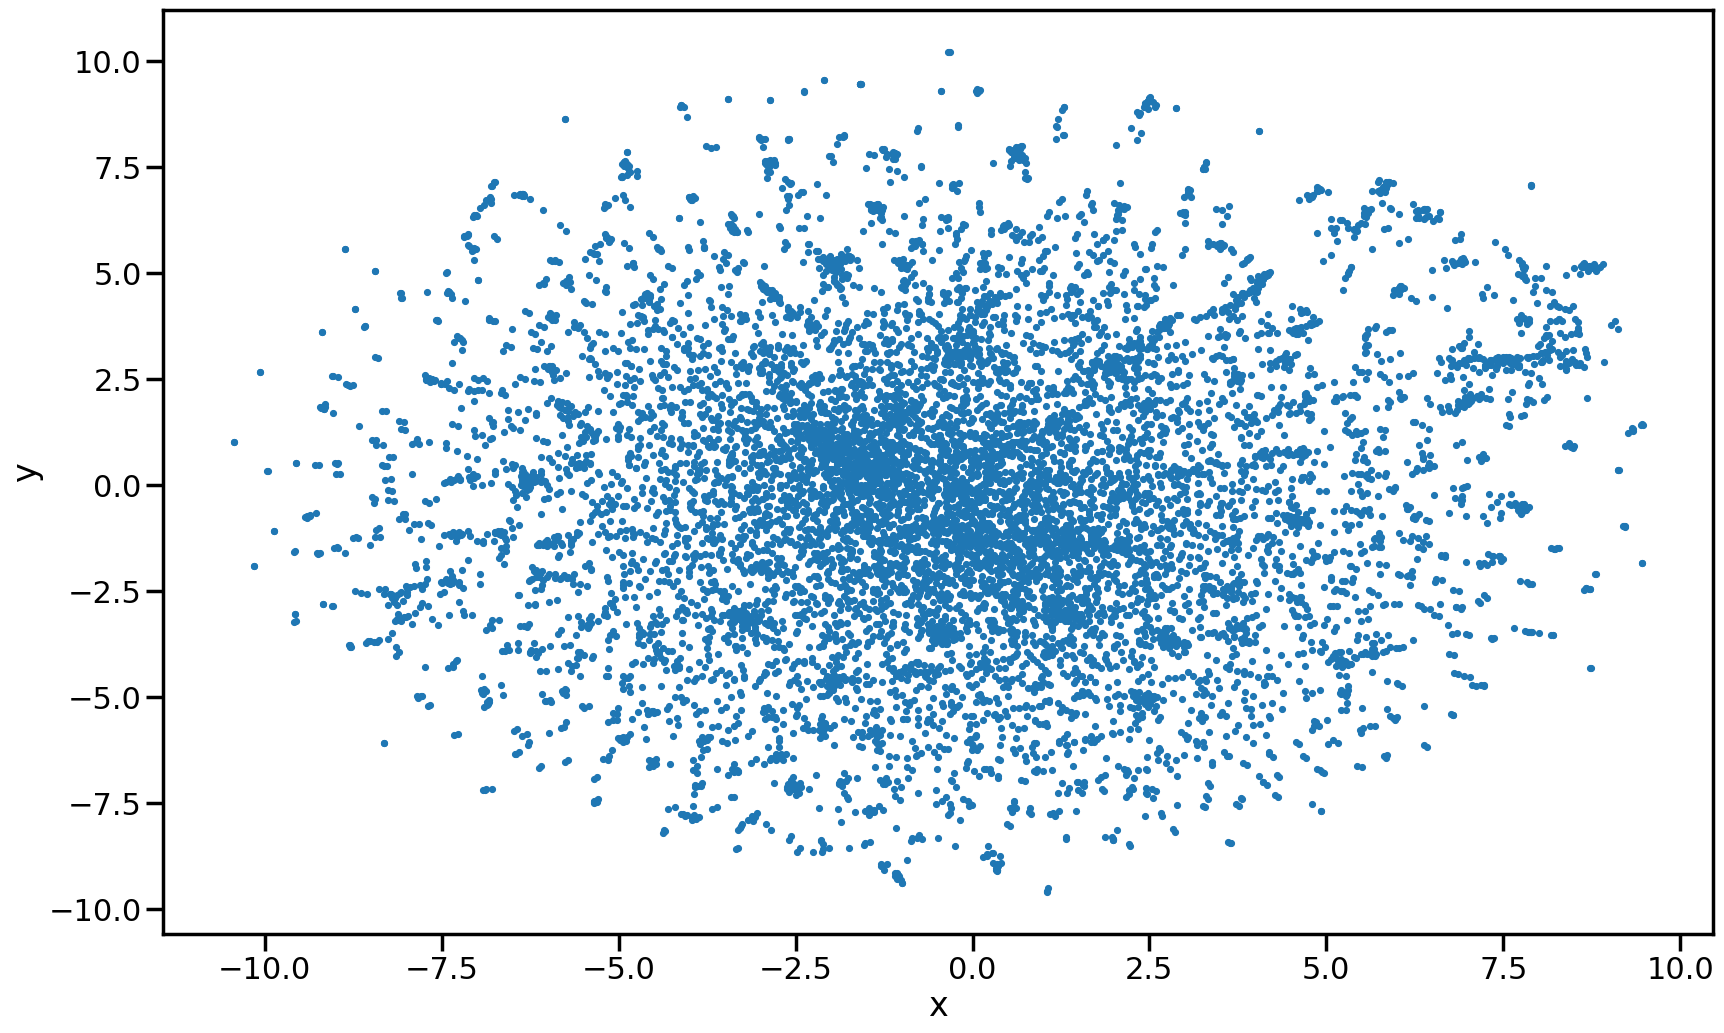

In [ ]:
points.plot.scatter("x", "y", s=10, figsize=(20, 12))

In [ ]:
def plot_region(x_bounds, y_bounds):
    slice = points[
        (x_bounds[0] <= points.x) &
        (points.x <= x_bounds[1]) &
        (y_bounds[0] <= points.y) &
        (points.y <= y_bounds[1]) 
    ]
    
    ax = slice.plot.scatter("x", "y", s=35, figsize=(10, 8))
    for i, point in slice.iterrows():
        ax.text(point.x + 0.005, point.y + 0.005, point.word, fontsize=11)

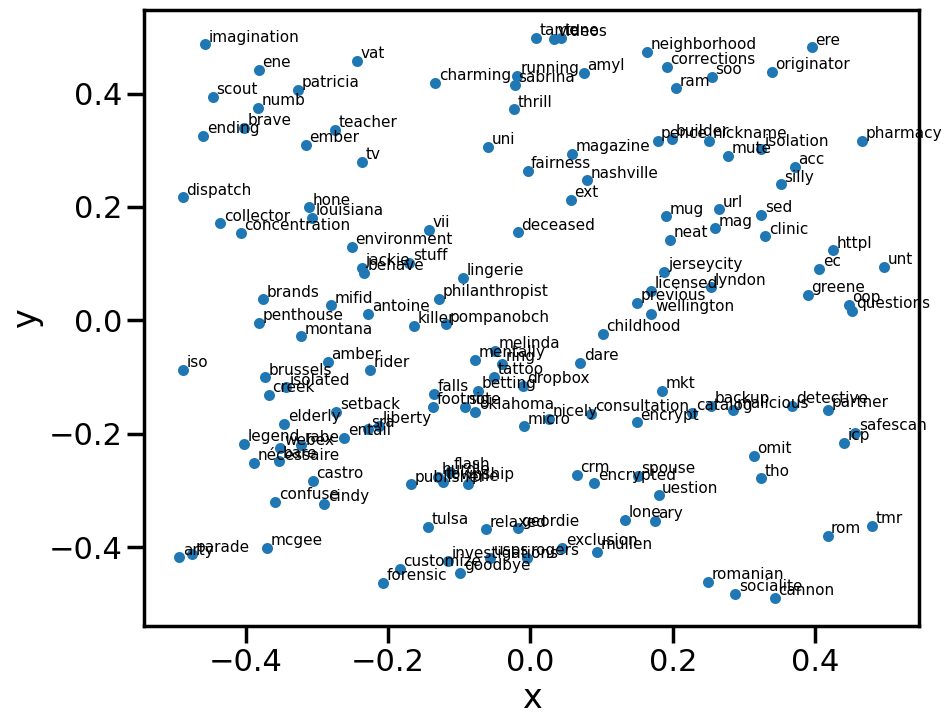

In [ ]:
plot_region(x_bounds=(-.5, .5), y_bounds=(-.5, .5))